In [1]:
from jax import config
config.update("jax_enable_x64", True)

import jax
from jax import lax
from jax import numpy as jnp
from jax.scipy.fft import dctn, idctn
import numpy as np
from functools import partial

from uot.solvers.back_and_forth.c_transform import c_transform_quadratic_fast
from uot.utils.central_gradient_nd import _central_gradient_nd

from collections.abc import Sequence
from typing import Optional
from functools import reduce

from uot.data.measure import GridMeasure

from functools import partial
from typing import Callable, Optional, Tuple, Dict, Any

from matplotlib import pyplot as plt

In [2]:
plt.rcParams['figure.dpi'] = 120  # Set the display DPI for inline plots
plt.rcParams['savefig.dpi'] = 120 # Set the default DPI for saved figures

## Few utility functions

In [3]:
def _wait_jax_finish(result: dict[str, Any]) -> dict[str, Any]:
    """Block until all JAX arrays in `result` are ready."""
    # tree_map was removed and need to use tree.map?
    # ну ебать его в рот, я хуй знает как оно там в джаксе
    return jax.tree.map(
        lambda x: x.block_until_ready() if isinstance(x, jax.Array) else x,
        result
    )


def _row_major_strides_py(shape):
    """Row-major (C-order) strides for flattening (static Python ints)."""
    d = len(shape)
    strides_py = []
    p = 1
    for k in range(d - 1, -1, -1):
        strides_py.insert(0, p)
        p *= shape[k]
    return strides_py


def _cell_centers_physical(shape, dtype):
    """
    Cell centers for n_i cells per axis:
        x_i = (i + 0.5) / n_i
    Returns x with shape (d, *shape).
    """
    d = len(shape)
    idx = jnp.indices(shape, dtype=dtype)  # (d, *shape)
    n_vec = jnp.array(shape, dtype=dtype).reshape((d,) + (1,) * d)
    return (idx + 0.5) / n_vec


def physical_to_index_cell_centered(y: jnp.ndarray, shape, *, clip_eps: float = 1e-6) -> jnp.ndarray:
    """
    Convert physical coords y in [0,1]^d to continuous index coords s suitable for CIC
    on a cell-centered grid (cell masses).

    y:     (d, *shape) physical coords
    shape: tuple of grid sizes (n1, n2, ..., nd)

    Returns:
      s: (d, *shape) continuous index coords where integer j corresponds to cell center.
         (So y=(j+0.5)/n  <=>  s=j.)
    """
    d = len(shape)
    n_vec = jnp.array(shape, dtype=y.dtype).reshape((d,) + (1,) * d)
    y = jnp.clip(y, 0.0, 1.0 - clip_eps)
    s = y * n_vec - 0.5
    return s


## Monge Map Construction

In [4]:
def monge_map_cic_from_psi_nd(psi: jnp.ndarray) -> jnp.ndarray:
    """
    Build a Monge map in index coordinates.
    """
    shape = psi.shape
    d = psi.ndim
    n_vec = jnp.array(shape, dtype=jnp.float32).reshape((d,) + (1,) * d)

    grad = _central_gradient_nd(psi)
    idx = jnp.indices(shape, dtype=jnp.float32)
    # s_raw = idx + 0.5 + grad * n_vec
    # s_raw = idx + grad * n_vec
    s_raw = idx - grad * n_vec
    clipped = []
    for ax in range(d):
        clipped.append(jnp.clip(s_raw[ax], 0.0, shape[ax] - 1.0))
    return jnp.stack(clipped, axis=0)

## Pushforward Procedures

In [5]:
def cic_pushforward_nd(
        density: jnp.ndarray,
        monge_map: jnp.ndarray,
        ) -> jnp.ndarray:
    """
    Pushforward a density field along the flow defined by psi.
    - density: (n_1, n_2, ..., n_d) array of nonnegative values
    - psi:     (n_1, n_2, ..., n_d) array of potential values
    Returns:
    - new_density: (n_1, n_2, ..., n_d) array of nonnegative values
    - grad: (d, n_1, n_2, ..., n_d) array of gradients of psi
    Assumes uniform grid on [0,1]^d with grid spacing h_i = 1/n_i.
    Uses multilinear interpolation (bilinear in 2D, trilinear in 3D, etc).
    Boundary: clamp to [0, n_k - 1] in each dimension.
    0.5*||x||^2 is implicit in the definition of psi.
    1. Compute grad psi
    2. Compute fractional index s = i + grad psi * n
       (vertex-centered interpretation)
    3. Clip s to [0, n_k - 1] in each dimension
    4. Compute base = floor(s) and frac = s - base
    5. Scatter density to 2^d corners with multilinear weights
    """
    shape = density.shape
    d = density.ndim
    mdtype = monge_map.dtype

    base = jnp.floor(monge_map).astype(jnp.int32)
    frac = monge_map - base.astype(mdtype)

    # --- flatten using static sizes (no int() on tracers) ---
    density_flat = density.reshape(-1)                     # OK: -1 uses static size
    base_flat    = base.reshape(d, -1)
    frac_flat    = frac.reshape(d, -1)

    strides = jnp.array(
        _row_major_strides_py(shape),
        dtype=jnp.int32,
        ).reshape(d, 1)

    out = jnp.zeros_like(density_flat)

    def corner_body(m, out_acc):
        bits = jnp.array([(m >> k) & 1 for k in range(d)], dtype=jnp.int32).reshape(d, 1)
        corner_idx = base_flat + bits                      # (d,N)
        w = jnp.where(bits == 1, frac_flat, 1.0 - frac_flat)
        w = jnp.prod(w, axis=0)                            # (N,)
        flat_idx = jnp.sum(corner_idx * strides, axis=0)   # (N,)
        return out_acc.at[flat_idx].add(density_flat * w)

    out = lax.fori_loop(0, 1 << d, corner_body, out)
    return out.reshape(shape)

In [6]:
@partial(jax.jit, static_argnames=('maxiterations', 'progressbar',
                                  'stepsize_lower_bound', 'error_metric',
                                  'monge_map_fn',
                                  'pushforward_fn'))
def backnforth_sqeuclidean_nd(
        mu: jnp.ndarray,                 # shape (n0,...,nd-1)
        nu: jnp.ndarray,                 # shape (n0,...,nd-1)
        coordinates: list[jnp.ndarray],  # len d, each length n_k
        stepsize: float,
        maxiterations: int,
        tolerance: float = 1e-4,
        progressbar: bool = False,
        pushforward_fn=cic_pushforward_nd,
        monge_map_fn=monge_map_cic_from_psi_nd,
        stepsize_lower_bound: float = 0.01,
        error_metric: str = 'h1_psi_relative',
    ):
    """
    Dimension-agnostic BFM with quadratic cost on a uniform tensor grid in [0,1]^d.

    error_metric: 'tv_psi' | 'tv_phi' | 'l_inf_psi' | 'h1_psi' | 'h1_psi_relative'
                  | 'transportation_cost' | 'transportation_cost_relative'
    """

    # checks (lightweight; keep in Python tracer-friendly)
    shape = mu.shape
    assert nu.shape == shape
    d = len(coordinates)
    assert d == mu.ndim == nu.ndim
    for k in range(d):
        assert coordinates[k].shape[0] == shape[k]
    init_stepsize = stepsize
    armijo_upper = 0.75
    armijo_lower = 0.25
    armijo_scale_down = 0.95


    # c-transform for quadratic cost
    c_transform = partial(c_transform_quadratic_fast, coords_list=coordinates)

    # precompute kernel and r^2 grid
    hs = [c[1] - c[0] for c in coordinates]         # cell width
    Ls = [hs[k] * shape[k] for k in range(d)]       # true length = N*h
    # Ls = [coord[-1] for coord in coordinates]
    kernel = neumann_kernel_nd(shape, Ls, dtype=mu.dtype)
    xmins = jnp.array([c[0] - 0.5*hs[k] for k,c in enumerate(coordinates)])
    xmaxs = jnp.array([c[-1] + 0.5*hs[k] for k,c in enumerate(coordinates)])
    r2 = _r2_from_coords(coordinates)
    cell_vol = jnp.prod(jnp.array([c[1] - c[0] for c in coordinates], dtype=mu.dtype))
    mu_nu_grid_sum = 0.5 * (r2 * (mu + nu)).sum()


    def dct_neumann_poisson(f):
        f = f - f.mean()
        Fh = _dctn(f)
        Uh = Fh / kernel
        Uh = Uh.at[(0,)*f.ndim].set(0.0)
        u = _idctn(Uh)
        return u - u.mean()

    def update_potential(phi, rho, target, sigma):
        residual = target - rho
        pde_solution = dct_neumann_poisson(residual)
        new_phi = phi + sigma * pde_solution
        grad_sq = cell_vol * jnp.vdot(residual, pde_solution).real
        return new_phi, pde_solution, grad_sq

    # Dual objective (quadratic cost):  ½∫|x|² (μ+ν) - ∫ν φ - ∫μ ψ
    def dual_value(phi, psi):
        return cell_vol * (mu_nu_grid_sum - (phi * mu).sum() - (psi * nu).sum())

    # Armijo–Goldstein heuristic
    def stepsize_update(sigma, value, old_value, grad_sq,
                        upper=armijo_upper,
                        lower=armijo_lower,
                        scale_down=armijo_scale_down):
        scale_up = 1.0 / scale_down
        gain = value - old_value
        old_sigma = sigma
        sigma = jnp.where(
            gain > sigma * upper * grad_sq,
            sigma * scale_up, sigma
        )
        sigma = jnp.where(
            gain < sigma * lower * grad_sq,
            sigma * scale_down, sigma
        )
        sigma = jnp.maximum(sigma, stepsize_lower_bound)
        return sigma

    def compute_error(iter_idx, dual_curr, dual_prev, grad_curr, grad_prev,
                      rho_mu=None, rho_nu=None):
        if error_metric == 'tv_psi':
            err = 0.5 * jnp.sum(jnp.abs(rho_mu - nu))
        elif error_metric == 'tv_phi':
            err = 0.5 * jnp.sum(jnp.abs(rho_nu - mu))
        elif error_metric == 'l_inf_psi':
            err = jnp.max(jnp.abs(rho_mu - nu))
        elif error_metric == 'h1_psi':
            err = grad_curr
        elif error_metric == 'h1_psi_relative':
            err = jnp.where(
                iter_idx == 0,
                jnp.inf,
                jnp.abs(grad_prev - grad_curr) / jnp.maximum(grad_curr, 1e-10),
            )
        elif error_metric == 'transportation_cost':
            err = jnp.abs(dual_prev - dual_curr)
        elif error_metric == 'transportation_cost_relative':
            err = jnp.where(
                iter_idx == 0,
                jnp.inf,
                jnp.abs(dual_prev - dual_curr) / jnp.maximum(jnp.abs(dual_curr), 1e-10),
            )
        else:
            raise ValueError(f"Unknown error_metric: {error_metric}")
        return err
    def body(state):
        (i, phi, psi, sigma, dual_prev, grad_prev,
         errors, dual_values, sigma_history) = state

        monge_map_psi = monge_map_fn(psi)
        rho_mu = pushforward_fn(mu, monge_map_psi)
        phi, _, _ = update_potential(phi, rho_mu, nu, sigma)
        psi = c_transform(phi)
        # phi = c_transform(psi)  # ensure consistency

        monge_map_phi = monge_map_fn(phi)
        rho_nu = pushforward_fn(nu, monge_map_phi)
        psi, _, grad_sq_psi = update_potential(psi, rho_nu, mu, sigma)
        phi = c_transform(psi)
        # psi = c_transform(phi)  # ensure consistency

        dual_curr = dual_value(phi, psi)
        sigma_new = stepsize_update(sigma, dual_curr, dual_prev, grad_sq_psi)
        err = compute_error(i, dual_curr, dual_prev, grad_sq_psi, grad_prev,
                            rho_mu=rho_mu, rho_nu=rho_nu)

        errors = errors.at[i].set(err)
        dual_values = dual_values.at[i].set(dual_curr)
        sigma_history = sigma_history.at[i].set(sigma_new)

        if progressbar:
            jax.debug.print("[{}] error = {}; dual = {};",
                            i, errors[i], dual_values[i])

        return (i + 1, phi, psi, sigma_new, dual_curr, grad_sq_psi,
                errors, dual_values, sigma_history)

    def cond(state):
        i = state[0]
        errors = state[6]
        curr_error = errors[jnp.maximum(i - 1, 0)]
        return (i < maxiterations) & (curr_error > tolerance)

    phi0 = jnp.zeros_like(mu)
    psi0 = jnp.zeros_like(nu)
    dual0 = dual_value(phi0, psi0)
    grad0 = 0.0

    errors0 = jnp.full((maxiterations,), jnp.inf, dtype=mu.dtype)
    dual_values0 = jnp.full((maxiterations,), dual0, dtype=mu.dtype)
    sigma_history0 = jnp.full((maxiterations,), stepsize, dtype=mu.dtype)

    init_state = (jnp.array(0, dtype=jnp.int32), phi0, psi0,
                  jnp.asarray(init_stepsize, dtype=mu.dtype), dual0, grad0,
                  errors0, dual_values0, sigma_history0)

    state = lax.while_loop(cond, body, init_state)
    iterations, phi, psi, _, _, _, errors, dual_values, sigma_history = state

    rho_mu = pushforward_fn(mu, monge_map_fn(psi))
    rho_nu = pushforward_fn(nu, monge_map_fn(phi))
    results = {
        'iterations': iterations,
        'phi': phi,
        'psi': psi,
        'rho_nu': rho_nu,
        'rho_mu': rho_mu,
        'errors': errors,
        'dual_history': dual_values,
        'sigma_history': sigma_history,
    }
    return results


def _r2_from_coords(coords):
    grids = jnp.meshgrid(*coords, indexing="ij")
    r2 = jnp.zeros_like(grids[0])
    for G in grids:
        r2 = r2 + G * G
    return r2


def _dctn(a):
    return dctn(a, type=2, norm="ortho")


def _idctn(a):
    return idctn(a, type=2, norm="ortho")


def neumann_kernel_nd(shape, lengths, dtype=jnp.float64):
    d = len(shape)
    hs = [L / N for L, N in zip(lengths, shape)]
    parts = []

    for i, (N, h) in enumerate(zip(shape, hs)):
        k = jnp.arange(N, dtype=dtype)
        lam1d = (4.0 / (h * h)) * jnp.sin(jnp.pi * k / (2 * N)) ** 2
        sh = (1,) * i + (N,) + (1,) * (d - i - 1)
        parts.append(jnp.reshape(lam1d, sh))

    Lam = jnp.sum(jnp.stack([jnp.broadcast_to(p, shape) for p in parts], axis=0), axis=0).astype(dtype)
    Lam = Lam.at[(0,) * d].set(jnp.inf)
    return Lam


---

# BARYCENTERS WITH BACK-AND-FORTH METHOD

In [ ]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice

from jax import config
config.update("jax_enable_x64", True)

sys.path.insert(0, os.path.abspath(os.path.join('..')))

import jax.numpy as jnp
from functools import partial
from collections.abc import Sequence
from typing import Callable, Optional

from uot.problems.generators import GaussianMixtureBarycenterGenerator
from uot.utils.costs import cost_euclid_squared

# from uot.solvers.back_and_forth.forward_pushforward import cic_pushforward_nd
from uot.solvers.back_and_forth.c_transform import c_transform_quadratic_fast

from uot.solvers.back_and_forth.barycenter import backnforth_barycenter_sqeuclidean_nd_optimized


### Barycenter Problem Construction

In [8]:
def plot_measure(ax, measure, title, cmap='viridis'):
    if hasattr(measure, 'weights_nd') and hasattr(measure, 'axes'):
        axes = measure.axes
        weights = np.asarray(measure.weights_nd)
        if len(axes) == 1:
            x = np.asarray(axes[0])
            ax.plot(x, weights.reshape(-1))
            ax.set_title(title)
            ax.grid(True, alpha=0.3)
            return
        extent = (
            float(axes[0][0]), float(axes[0][-1]),
            float(axes[1][0]), float(axes[1][-1]),
        )
        ax.imshow(weights.T, extent=extent, origin='lower', cmap=cmap)
        ax.set_title(title)
        ax.set_axis_off()
        return

    points, weights = measure.to_discrete()
    points = np.asarray(points)
    weights = np.asarray(weights)
    if points.ndim == 1:
        points = points.reshape(-1, 1)
    if points.shape[1] == 1:
        ax.plot(points[:, 0], weights)
    else:
        ax.scatter(points[:, 0], points[:, 1], c=weights, s=8, cmap=cmap)
    ax.set_title(title)
    ax.set_axis_off()


In [9]:
# Instantiate the generator (2D case).

gen = GaussianMixtureBarycenterGenerator(
    name="gmm-bary",
    dim=2,
    num_components=1,
    n_points=32,
    num_datasets=3,
    borders=(0.0, 1.0),
    cost_fn=cost_euclid_squared,
    num_marginals=3,
    use_jax=True,
    seed=42,
    measure_mode="grid",
    cell_discretization="cell-centered",
)

problems = list(islice(gen.generate(), 3))


### Helper functions to solve Poisson Equation

In [10]:
def _r2_from_coords(coords):
    grids = jnp.meshgrid(*coords, indexing="ij")
    r2 = jnp.zeros_like(grids[0])
    for G in grids:
        r2 = r2 + G * G
    return r2


def _dctn(a):
    return dctn(a, type=2, norm="ortho")


def _idctn(a):
    return idctn(a, type=2, norm="ortho")


def neumann_kernel_nd(shape, lengths, dtype=jnp.float64):
    d = len(shape)
    hs = [L / N for L, N in zip(lengths, shape)]
    parts = []

    for i, (N, h) in enumerate(zip(shape, hs)):
        k = jnp.arange(N, dtype=dtype)
        lam1d = (4.0 / (h * h)) * jnp.sin(jnp.pi * k / (2 * N)) ** 2
        sh = (1,) * i + (N,) + (1,) * (d - i - 1)
        parts.append(jnp.reshape(lam1d, sh))

    Lam = jnp.sum(jnp.stack([jnp.broadcast_to(p, shape) for p in parts], axis=0), axis=0).astype(dtype)
    Lam = Lam.at[(0,) * d].set(jnp.inf)
    return Lam


### Entropic Barycenter Back-and-Forth method

In [11]:
def entropic_barycenter_sobolev_gradient_ascent_dual(
    mu_list: Sequence[jnp.ndarray],
    lambda_list: Sequence[float] | jnp.ndarray,
    coordinates: Sequence[jnp.ndarray],
    gamma: float,
    *,
    num_outer_iters: int = 30,
    outer_tol: Optional[float] = None,
    mismatch_norm: str = "l2",
    pushforward_fn: Callable = cic_pushforward_nd,
    verbose: bool = True,
):
    """
    Entropic barycenter with ψ-first then φ outer updates.
    """
    # Additional checks
    if len(mu_list) == 0:
        raise ValueError("mu_list must contain at least one marginal.")
    if gamma <= 0:
        raise ValueError("gamma must be strictly positive.")

    # NOTE: For now we will use stack of mu measures in python list
    mus = [jnp.asarray(mu) for mu in mu_list]
    shape = mus[0].shape
    for i, mu in enumerate(mus):
        if mu.shape != shape:
            raise ValueError(f"All marginals must share one grid shape. mu_list[0]={shape}, mu_list[{i}]={mu.shape}.")

    # NOTE: weights normalization (just to be sure)
    weights = jnp.asarray(lambda_list, dtype=mus[0].dtype)
    if weights.ndim != 1 or weights.shape[0] != len(mus):
        raise ValueError(f"lambda_list must have shape ({len(mus)},), got {weights.shape}.")
    weights = weights / jnp.maximum(weights.sum(), jnp.finfo(weights.dtype).eps)

    c_transform = partial(c_transform_quadratic_fast, coords_list=coordinates)

    # NOTE: define kernel for poisson solver
    Ls = [coord[-1] for coord in coordinates]
    kernel = neumann_kernel_nd(shape, Ls, dtype=mu.dtype)

    psi_list = [jnp.zeros_like(mu) for mu in mus]
    phi_list = [c_transform(psi_i) for psi_i in psi_list]

    mass_hist = []
    source_mismatch_hist = []
    max_source_mismatch_hist = []

    # history trackers
    phi_hist = []
    psi_hist = []
    nu_tilde_hist = []
    mu_tilde_hist = []
    # phase-specific histories: after phi update and after psi update
    phi_hist_after_phi = []
    psi_hist_after_phi = []
    nu_tilde_hist_after_phi = []
    mu_tilde_hist_after_phi = []
    nu_hist_after_phi = []

    phi_hist_after_psi = []
    psi_hist_after_psi = []
    nu_tilde_hist_after_psi = []
    mu_tilde_hist_after_psi = []
    nu_hist_after_psi = []

    def dct_neumann_poisson(f):
        f = f - f.mean()
        Fh = _dctn(f)
        Uh = Fh / kernel
        Uh = Uh.at[(0,)*f.ndim].set(0.0)
        u = _idctn(Uh)
        return u - u.mean()
    
    def h1_gradient(rho, target):
        residual = target - rho
        pde_solution = dct_neumann_poisson(residual)
        return pde_solution
    
    def gibbs_nu(phi_list):
        phi_stack = jnp.stack(phi_list, axis=0)
        A = jnp.tensordot(weights, phi_stack, axes=(0, 0))
        logits = -(A / jnp.asarray(gamma, dtype=phi_stack.dtype))
        nu = jnp.exp(logits)
        nu = nu / jnp.maximum(nu.sum(), jnp.finfo(nu.dtype).eps)
        return nu

    # TODO: define update of the stepsize
    eta = 4.

    # ----- MAIN CYCLE -----
    for k in range(num_outer_iters):
        nu_mismatches = []
        mu_mismatches = []

        # (1) ctransform(ψ) -> φ
        phi_list = [c_transform(psi_i) for psi_i in psi_list]

        # (2) Gibbs ν from current φ's
        nu = gibbs_nu(phi_list)

        # (3)-(4) compute μ~_i and update φ_i
        phi_next = []
        nu_tilde_list = []
        for i, (mu, weight) in enumerate(zip(mus, weights)):
            psi_i = c_transform(phi_list[i])
            # nu_tilde_i = pushforward_fn(mu, -psi_i)
            nu_tilde_i = pushforward_fn(
                mu,
                monge_map_cic_from_psi_nd(psi_i),
                )
            # nu_tilde_i = pushforward_fn(mu, phi_list[i])
            nu_tilde_list.append(nu_tilde_i)

            # NOTE: perform gradient update of i-th potential phi
            delta = h1_gradient(weight * nu_tilde_i, weight * nu)
            phi_next_i = phi_list[i] + eta * delta
            phi_next.append(phi_next_i)

            # NOTE: we use L1 mismatch norm
            mismatch_i = float(jnp.sum(jnp.abs(nu - nu_tilde_i)))
            nu_mismatches.append(mismatch_i)

        phi_list = phi_next

        # recompute nu after phi update (for history)
        nu_phi = gibbs_nu(phi_list)
        mu_tilde_list_phi = []
        for i, (mu, weight) in enumerate(zip(mus, weights)):
            phi_i = phi_list[i]
            mu_tilde_i_phi = pushforward_fn(
                nu_phi,
                monge_map_cic_from_psi_nd(phi_i),
            )
            mu_tilde_list_phi.append(mu_tilde_i_phi)

        # store histories after phi update
        phi_hist_after_phi.append(phi_list)
        psi_hist_after_phi.append(psi_list)
        nu_tilde_hist_after_phi.append(nu_tilde_list)
        mu_tilde_hist_after_phi.append(mu_tilde_list_phi)
        nu_hist_after_phi.append(nu_phi)

        # (5) ctransform(φ) -> ψ
        psi_list = [c_transform(phi_i) for phi_i in phi_list]

        # (6) Gibbs ν from current φ's
        nu = gibbs_nu(phi_list)

        # (7)-(8) compute pushforward nu through φ_i and update ψ_i
        psi_next = []
        mu_tilde_list = []
        for i, (mu, weight) in enumerate(zip(mus, weights)):
            # phi_i = c_transform(psi_list[i])
            mu_tilde_i = pushforward_fn(
                nu,
                # monge_map_cic_from_psi_nd(phi_i),
                monge_map_cic_from_psi_nd(phi_list[i]),
                )
            # mu_tilde_i = pushforward_fn(nu, psi_i)
            # mu_tilde_i = pushforward_fn(nu, psi_list[i])
            mu_tilde_list.append(mu_tilde_i)

            # NOTE: perform gradient update of i-th potential psi
            delta = h1_gradient(weight * mu, weight * mu_tilde_i)
            # psi_next_i = psi_list[i] + eta * delta
            # psi_next.append(psi_next_i)

            # NOTE: we use L1 mismatch norm
            mismatch_i = float(jnp.sum(jnp.abs(mu - mu_tilde_i)))
            mu_mismatches.append(mismatch_i)

        # psi_list = psi_next

        # compute histories after psi update
        phi_list_after_psi = [c_transform(psi_i) for psi_i in psi_list]
        nu_psi = gibbs_nu(phi_list_after_psi)
        nu_tilde_list_psi = []
        mu_tilde_list_psi = []
        for i, (mu, weight) in enumerate(zip(mus, weights)):
            psi_i = psi_list[i]
            nu_tilde_i_psi = pushforward_fn(
                mu,
                monge_map_cic_from_psi_nd(psi_i),
            )
            nu_tilde_list_psi.append(nu_tilde_i_psi)

            phi_i = phi_list_after_psi[i]
            mu_tilde_i_psi = pushforward_fn(
                nu_psi,
                monge_map_cic_from_psi_nd(phi_i),
            )
            mu_tilde_list_psi.append(mu_tilde_i_psi)

        phi_hist_after_psi.append(phi_list_after_psi)
        psi_hist_after_psi.append(psi_list)
        nu_tilde_hist_after_psi.append(nu_tilde_list_psi)
        mu_tilde_hist_after_psi.append(mu_tilde_list_psi)
        nu_hist_after_psi.append(nu_psi)


        max_mismatch = jnp.max(jnp.asarray(mu_mismatches))
        mass_nu = nu.sum()

        mass_hist.append(mass_nu)
        source_mismatch_hist.append(mu_mismatches)
        max_source_mismatch_hist.append(max_mismatch)


        if verbose:
            mismatch_str = ", ".join(f"{m:.3e}" for m in mu_mismatches)
            print(
                f"[outer {k + 1:03d}] mass(nu)={mass_nu:.8f} "
                f"||mu_i-(S_i)#nu||=({mismatch_str}) max={max_mismatch:.3e}"
            )
        
        if outer_tol is not None and max_mismatch <= float(outer_tol):
            break

    phi_list = [c_transform(psi_i) for psi_i in psi_list]
    # final ν from final φ
    nu_final = gibbs_nu(phi_list)

    diagnostics = {
        "iterations": len(mass_hist),
        "mass_nu": jnp.asarray(mass_hist, dtype=mus[0].dtype),
        "source_mismatch": jnp.asarray(source_mismatch_hist, dtype=mus[0].dtype),
        "max_source_mismatch": jnp.asarray(max_source_mismatch_hist, dtype=mus[0].dtype),
        "phi_hist_after_phi": jnp.stack([jnp.stack(p, axis=0) for p in phi_hist_after_phi], axis=0) if phi_hist_after_phi else None,
        "psi_hist_after_phi": jnp.stack([jnp.stack(p, axis=0) for p in psi_hist_after_phi], axis=0) if psi_hist_after_phi else None,
        "nu_tilde_hist_after_phi": jnp.stack([jnp.stack(p, axis=0) for p in nu_tilde_hist_after_phi], axis=0) if nu_tilde_hist_after_phi else None,
        "mu_tilde_hist_after_phi": jnp.stack([jnp.stack(p, axis=0) for p in mu_tilde_hist_after_phi], axis=0) if mu_tilde_hist_after_phi else None,
        "nu_hist_after_phi": jnp.stack(nu_hist_after_phi, axis=0) if nu_hist_after_phi else None,
        "phi_hist_after_psi": jnp.stack([jnp.stack(p, axis=0) for p in phi_hist_after_psi], axis=0) if phi_hist_after_psi else None,
        "psi_hist_after_psi": jnp.stack([jnp.stack(p, axis=0) for p in psi_hist_after_psi], axis=0) if psi_hist_after_psi else None,
        "nu_tilde_hist_after_psi": jnp.stack([jnp.stack(p, axis=0) for p in nu_tilde_hist_after_psi], axis=0) if nu_tilde_hist_after_psi else None,
        "mu_tilde_hist_after_psi": jnp.stack([jnp.stack(p, axis=0) for p in mu_tilde_hist_after_psi], axis=0) if mu_tilde_hist_after_psi else None,
        "nu_hist_after_psi": jnp.stack(nu_hist_after_psi, axis=0) if nu_hist_after_psi else None,
    }
    return nu_final, psi_list, phi_list, diagnostics


In [ ]:
def _stack_grid_measures(measures):
    weights = []
    for measure in measures:
        if hasattr(measure, 'weights_nd'):
            weights.append(jnp.asarray(measure.weights_nd))
        else:
            raise ValueError("Expected GridMeasure with weights_nd for plotting/solver inputs.")
    return jnp.stack(weights, axis=0)


def _plot_density(ax, density, grid_axes, title, cmap='viridis'):
    if len(grid_axes) == 1:
        x = np.asarray(grid_axes[0])
        y = np.asarray(density).reshape(-1)
        ax.plot(x, y)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        return
    if len(grid_axes) == 2:
        extent = (
            float(grid_axes[0][0]), float(grid_axes[0][-1]),
            float(grid_axes[1][0]), float(grid_axes[1][-1]),
        )
        ax.imshow(np.asarray(density).T, extent=extent, origin='lower', cmap=cmap)
        ax.set_title(title)
        ax.set_axis_off()
        return
    raise ValueError(f"Unsupported grid dimension: {len(grid_axes)}")


problem = problems[1]
measures = problem.get_marginals()
grid_axes = measures[0].axes
stacked = _stack_grid_measures(measures)
lambdas = jnp.asarray(problem.lambdas())

nu_reg, psi_reg, phi_reg, diag_reg = entropic_barycenter_sobolev_gradient_ascent_dual(
    mu_list=[stacked[i] for i in range(stacked.shape[0])],
    lambda_list=lambdas,
    coordinates=grid_axes,
    gamma=1e-3,
    num_outer_iters=150,
    # eta=1.0,
    outer_tol=5e-4,
    pushforward_fn=cic_pushforward_nd,
    verbose=True,
)

print(f"Back-and-Forth (entropic, psi-first) outer iterations = {diag_reg['iterations']}")
print(f"Last mass(nu) = {float(diag_reg['mass_nu'][-1]):.8f}")
print(f"Last max_i ||mu_i-(S_i)#nu|| = {float(diag_reg['max_source_mismatch'][-1]):.3e}")

nu_reg = nu_reg / jnp.maximum(nu_reg.sum(), 1e-12)

[outer 001] mass(nu)=1.00000000 ||mu_i-(S_i)#nu||=(1.747e+00, 1.703e+00, 1.874e+00) max=1.874e+00
[outer 002] mass(nu)=1.00000000 ||mu_i-(S_i)#nu||=(1.725e+00, 1.682e+00, 1.865e+00) max=1.865e+00
[outer 003] mass(nu)=1.00000000 ||mu_i-(S_i)#nu||=(1.704e+00, 1.661e+00, 1.856e+00) max=1.856e+00
[outer 004] mass(nu)=1.00000000 ||mu_i-(S_i)#nu||=(1.681e+00, 1.639e+00, 1.847e+00) max=1.847e+00
[outer 005] mass(nu)=1.00000000 ||mu_i-(S_i)#nu||=(1.659e+00, 1.618e+00, 1.837e+00) max=1.837e+00
[outer 006] mass(nu)=1.00000000 ||mu_i-(S_i)#nu||=(1.635e+00, 1.596e+00, 1.828e+00) max=1.828e+00
[outer 007] mass(nu)=1.00000000 ||mu_i-(S_i)#nu||=(1.612e+00, 1.574e+00, 1.818e+00) max=1.818e+00
[outer 008] mass(nu)=1.00000000 ||mu_i-(S_i)#nu||=(1.589e+00, 1.553e+00, 1.808e+00) max=1.808e+00
[outer 009] mass(nu)=1.00000000 ||mu_i-(S_i)#nu||=(1.565e+00, 1.531e+00, 1.799e+00) max=1.799e+00
[outer 010] mass(nu)=1.00000000 ||mu_i-(S_i)#nu||=(1.542e+00, 1.510e+00, 1.789e+00) max=1.789e+00
[outer 011] mass(nu)

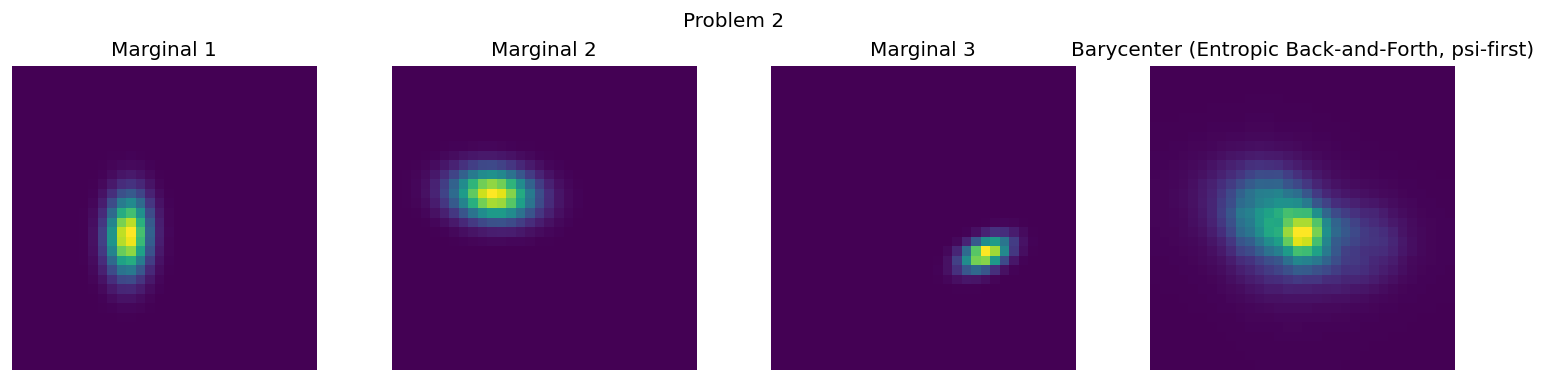

In [17]:
num_measures = len(measures)
fig, axes_arr = plt.subplots(1, num_measures + 1, figsize=(3.2 * (num_measures + 1), 3.2))
if num_measures + 1 == 1:
    axes_arr = [axes_arr]

for j, measure in enumerate(measures, start=1):
    plot_measure(axes_arr[j - 1], measure, f"Marginal {j}")

_plot_density(axes_arr[num_measures], nu_reg, grid_axes, "Barycenter (Entropic Back-and-Forth, psi-first)")

fig.suptitle("Problem 2")
plt.tight_layout()
plt.show()

In [18]:
# Back-and-forth barycenter (library solver)
mu_bf, diag_bf = backnforth_barycenter_sqeuclidean_nd_optimized(
    weights=lambdas,
    measures_weights=stacked,
    coordinates=grid_axes,
    outer_maxiter=50,
    stopping_tol=5e-4,
    transport_maxiter=500,
    transport_tol=1e-3,
    # pushforward_fn=cic_pushforward_nd,
)
mu_bf = mu_bf / jnp.maximum(mu_bf.sum(), 1e-12)


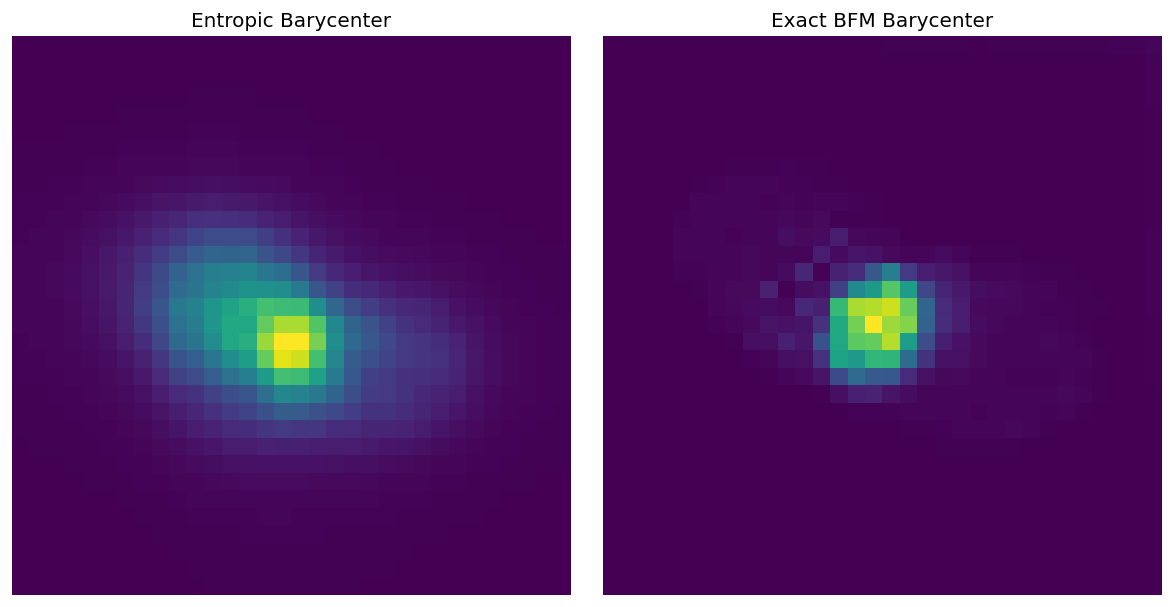

In [19]:
# 2D barycenter comparison (side-by-side)
fig_bary, axes_bary = plt.subplots(nrows=1, ncols=2, figsize=(10.0, 5.0))

_plot_density(axes_bary[0], nu_reg, grid_axes, "Entropic Barycenter")
_plot_density(axes_bary[1], mu_bf, grid_axes, "Exact BFM Barycenter")

plt.tight_layout()
plt.show()


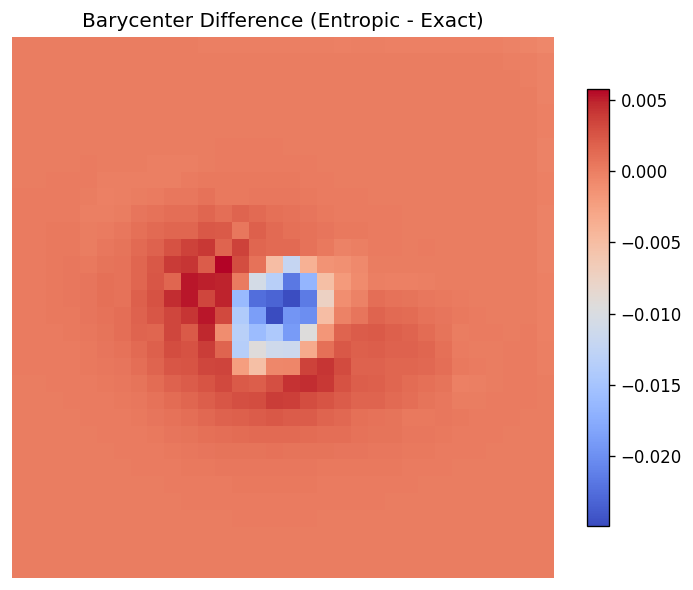

In [20]:
# 2D barycenter difference (entropic - exact)
fig_diff, ax_diff = plt.subplots(nrows=1, ncols=1, figsize=(6.0, 5.0))

diff = np.asarray(nu_reg) - np.asarray(mu_bf)
extent = (
    float(grid_axes[0][0]), float(grid_axes[0][-1]),
    float(grid_axes[1][0]), float(grid_axes[1][-1]),
)
img = ax_diff.imshow(diff.T, extent=extent, origin='lower', cmap='coolwarm')
ax_diff.set_title("Barycenter Difference (Entropic - Exact)")
ax_diff.set_axis_off()
fig_diff.colorbar(img, ax=ax_diff, shrink=0.8)

plt.tight_layout()
plt.show()


---

# TOY GENERATOR (2D) COMPARISON


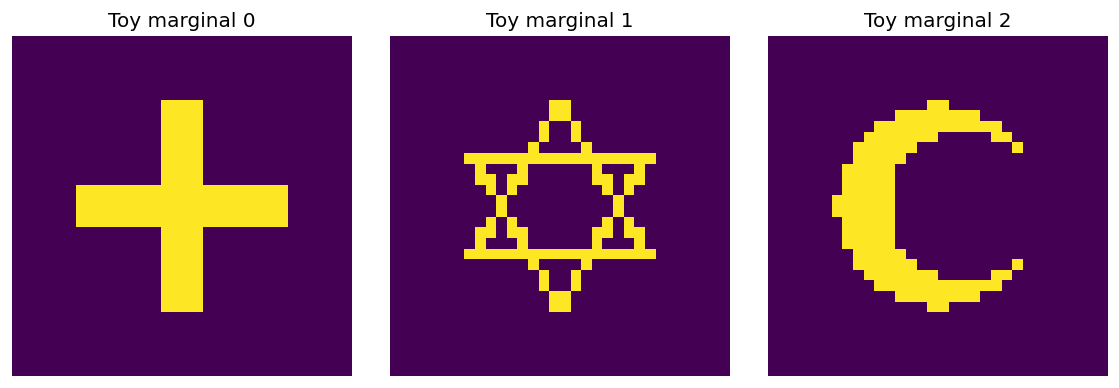

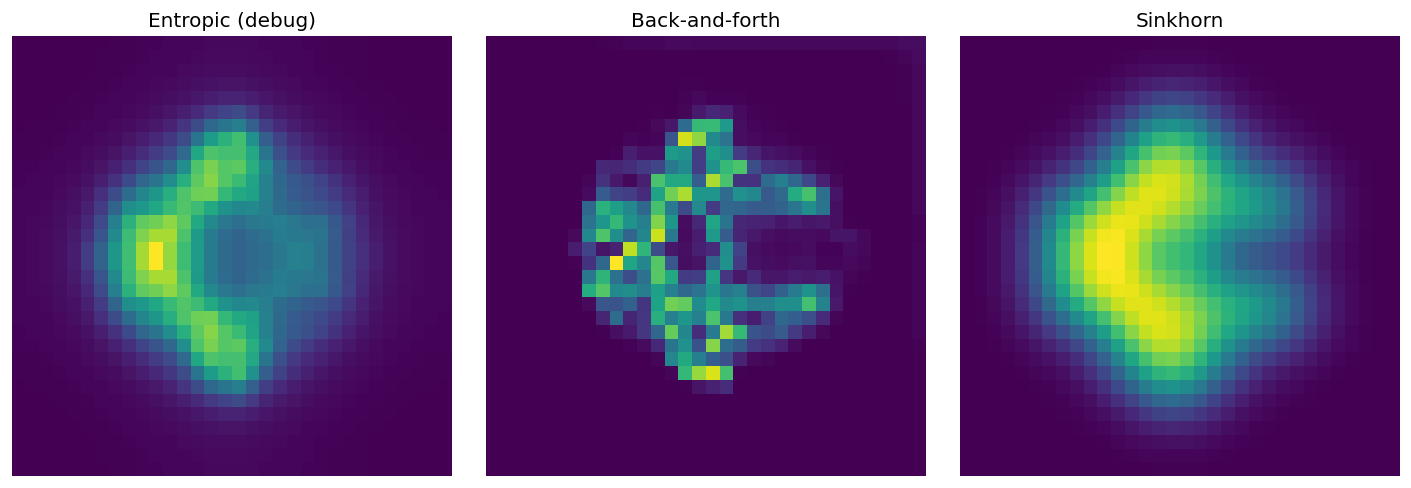

In [22]:
from uot.problems.generators.toy_barycenter_generator import ToyBarycenterGenerator, FixedListSelector
from uot.solvers.back_and_forth.barycenter import backnforth_barycenter_sqeuclidean_nd_optimized
from uot.solvers.sinkhorn.barycenter import barycenter_sinkhorn

# Build a 2D toy barycenter problem with 3 marginals
selector = FixedListSelector(("Plus", "Star", "Crescent"))
toy_gen = ToyBarycenterGenerator(
    selector=selector,
    n_points=32,
    cost_fn=cost_euclid_squared,
    num_datasets=1,
    measure_mode="grid",
    use_jax=False,
    cell_discretization="cell-centered",
)

toy_problem = next(toy_gen.generate(num_marginals=3))
toy_measures = toy_problem.get_marginals()
toy_axes = toy_measures[0].axes
toy_stacked = _stack_grid_measures(toy_measures)
toy_lambdas = jnp.asarray(toy_problem.lambdas())

# Entropic barycenter (debug solver)
nu_toy, _, _, diag_toy = entropic_barycenter_sobolev_gradient_ascent_dual(
    mu_list=[toy_stacked[i] for i in range(toy_stacked.shape[0])],
    lambda_list=toy_lambdas,
    coordinates=toy_axes,
    gamma=1e-3,
    num_outer_iters=150,
    outer_tol=5e-4,
    pushforward_fn=cic_pushforward_nd,
    verbose=False,
)
nu_toy = nu_toy / jnp.maximum(nu_toy.sum(), 1e-12)

# Back-and-forth barycenter (library solver)
mu_bf_toy, diag_bf_toy = backnforth_barycenter_sqeuclidean_nd_optimized(
    weights=toy_lambdas,
    measures_weights=toy_stacked,
    coordinates=toy_axes,
    outer_maxiter=50,
    stopping_tol=5e-4,
    transport_maxiter=500,
    transport_tol=1e-3,
    # pushforward_fn=cic_pushforward_nd,
)
mu_bf_toy = mu_bf_toy / jnp.maximum(mu_bf_toy.sum(), 1e-12)

# Sinkhorn barycenter on shared support
support, meas_array, cost_matrix, lambdas = toy_problem.shared_support_inputs(
    include_zeros=True,
)
b_sinkhorn, info_sinkhorn = barycenter_sinkhorn(
    measures=jnp.asarray(meas_array),
    cost=jnp.asarray(cost_matrix),
    lambdas=jnp.asarray(lambdas),
    reg=1e-2,
    tol=1e-4,
    maxiter=400,
    return_diagnostics=True,
)

# reshape sinkhorn barycenter to grid for plotting
shape = tuple(len(ax) for ax in toy_axes)
b_sinkhorn_grid = np.asarray(b_sinkhorn).reshape(shape)

# Plot marginals
fig_marg, axes_marg = plt.subplots(1, len(toy_measures), figsize=(3.2 * len(toy_measures), 3.2))
if len(toy_measures) == 1:
    axes_marg = [axes_marg]
for i, m in enumerate(toy_measures):
    plot_measure(axes_marg[i], m, f"Toy marginal {i}")
plt.tight_layout()
plt.show()

# Plot barycenters side-by-side (2D)
fig_bary, axes_bary = plt.subplots(1, 3, figsize=(12.0, 4.0))
_plot_density(axes_bary[0], nu_toy, toy_axes, "Entropic (debug)")
_plot_density(axes_bary[1], mu_bf_toy, toy_axes, "Back-and-forth")
_plot_density(axes_bary[2], b_sinkhorn_grid, toy_axes, "Sinkhorn")
plt.tight_layout()
plt.show()
